In [1]:
from tqdm import tqdm
import numpy as np



import random
tqdm.pandas()
seed = 42
random.seed(seed)
np.random.seed(seed)


print(f"✅ Seed fixed to {seed}")

✅ Seed fixed to 42


c:\Users\rrpra\Documents\Github\git_testing\Phishing_URL_classifier_using_nlp_feature_extraction\S01_dataset_preprocessing_pipeline.py:77: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df2['label'][df2['label'] == 1] = 2
c:\Users\rrpra\Docum


DATASET: Malicious URLs [D1]
TRAIN → Safe: 342463, Phishing: 75269
VALID → Safe: 42809, Phishing: 9408
TEST → Safe: 42808, Phishing: 9409


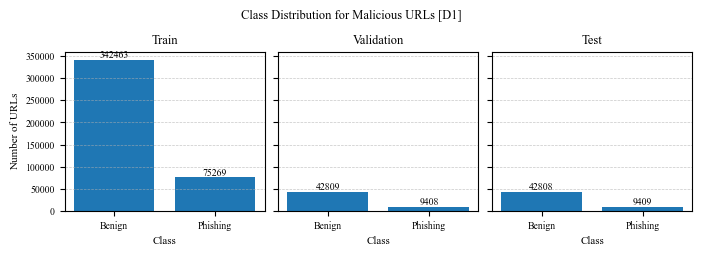


DATASET: UCI phiusiil-phishing [D2]
TRAIN → Safe: 107880, Phishing: 80416
VALID → Safe: 13485, Phishing: 10052
TEST → Safe: 13485, Phishing: 10052


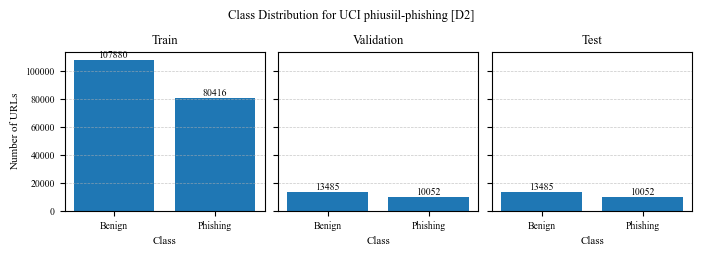


DATASET: kmack Phishing urls [D3]
TRAIN → Safe: 264169, Phishing: 263928
VALID → Safe: 33022, Phishing: 32991
TEST → Safe: 33021, Phishing: 32991


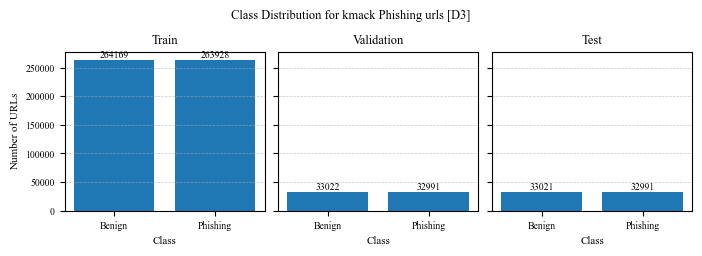


DATASET: kaggels phishing site urls [D4]
TRAIN → Safe: 314318, Phishing: 91438
VALID → Safe: 39290, Phishing: 11430
TEST → Safe: 39289, Phishing: 11430


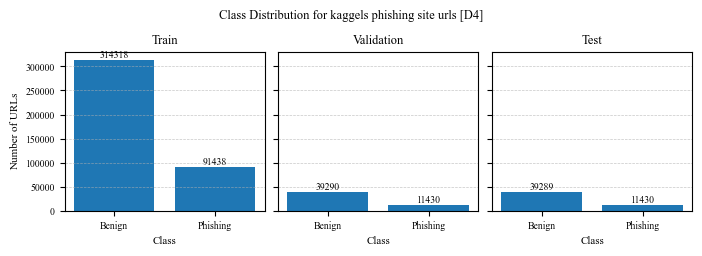

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from S01_dataset_preprocessing_pipeline import all_dataset
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

# IEEE-style global settings
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

def draw_ieee_bargraphs_for_dataset(dataset_name, splits):
    """
    IEEE-style bar graphs for Benign vs Phishing
    across Train / Validation / Test splits
    """

    split_names = ["Train", "Validation", "Test"]

    # IEEE single-column width ≈ 3.5 inches
    fig, axes = plt.subplots(
        1, 3,
        figsize=(7.0, 2.5),   # 2-column wide figure
        sharey=True
    )

    for ax, split_name, df in zip(axes, split_names, splits):

        benign = (df["label"] == 0).sum()
        phishing = (df["label"] == 1).sum()

        labels = ["Benign", "Phishing"]
        values = [benign, phishing]

        ax.bar(labels, values)
        ax.set_title(split_name)
        ax.set_xlabel("Class")
        ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)

        # Annotate bars
        for i, v in enumerate(values):
            ax.text(i, v, str(v), ha="center", va="bottom", fontsize=7)

    axes[0].set_ylabel("Number of URLs")

    fig.suptitle(
        f"Class Distribution for {dataset_name}",
        fontsize=9
    )

    plt.tight_layout(pad=0.8)
    plt.show()

gen = all_dataset()

for name, splits in gen:
    print(f"\n==============================")
    print(f"DATASET: {name}")
    print("==============================")

    for split_name, df in zip(['train', 'valid', 'test'], splits):
        safe = (df["label"] == 0).sum()
        phish = (df["label"] == 1).sum()
        print(f"{split_name.upper()} → Safe: {safe}, Phishing: {phish}")

    draw_ieee_bargraphs_for_dataset(name, splits)


In [3]:

def draw_boxplots_for_dataset(name, splits):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"URL Length Boxplots for Dataset: {name}", fontsize=14)

    for ax, (split_name, df) in zip(axs, zip(["train", "valid", "test"], splits)):

        # URL length
        df["url_len"] = df["url"].astype(str).apply(len)

        # Data groups
        overall = df["url_len"]
        safe = df[df["label"] == 0]["url_len"]
        phishing = df[df["label"] == 1]["url_len"]

        # Boxplot
        ax.boxplot(
            [overall, safe, phishing],
            labels=["Overall", "Safe", "Phishing"],
            showmeans=True
        )

        ax.set_title(f"{split_name.upper()} ({len(df)} URLs)")
        ax.set_ylabel("URL Length")
        ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()



gen = all_dataset()

for name, splits in gen:
    print(f"\n==============================")
    print(f"DATASET: {name}")
    print("==============================")

    # Print info + ratios
    for split_name, df in zip(['train', 'valid', 'test'], splits):

        print(f"\n--- {split_name.upper()} ---")
        print(f"Total URLs: {len(df)}")

        safe = (df["label"] == 0).sum()
        phish = (df["label"] == 1).sum()

        print(f"Safe (0): {safe}")
        print(f"Phishing (1): {phish}")
        print(f"Ratio: {safe}:{phish}")

    # Draw 3-subplot figure
    #draw_boxplots_for_dataset(name, splits)



DATASET: Malicious URLs [D1]

--- TRAIN ---
Total URLs: 417732
Safe (0): 342463
Phishing (1): 75269
Ratio: 342463:75269

--- VALID ---
Total URLs: 52217
Safe (0): 42809
Phishing (1): 9408
Ratio: 42809:9408

--- TEST ---
Total URLs: 52217
Safe (0): 42808
Phishing (1): 9409
Ratio: 42808:9409

DATASET: UCI phiusiil-phishing [D2]

--- TRAIN ---
Total URLs: 188296
Safe (0): 107880
Phishing (1): 80416
Ratio: 107880:80416

--- VALID ---
Total URLs: 23537
Safe (0): 13485
Phishing (1): 10052
Ratio: 13485:10052

--- TEST ---
Total URLs: 23537
Safe (0): 13485
Phishing (1): 10052
Ratio: 13485:10052

DATASET: kmack Phishing urls [D3]

--- TRAIN ---
Total URLs: 528097
Safe (0): 264169
Phishing (1): 263928
Ratio: 264169:263928

--- VALID ---
Total URLs: 66013
Safe (0): 33022
Phishing (1): 32991
Ratio: 33022:32991

--- TEST ---
Total URLs: 66012
Safe (0): 33021
Phishing (1): 32991
Ratio: 33021:32991

DATASET: kaggels phishing site urls [D4]

--- TRAIN ---
Total URLs: 405756
Safe (0): 314318
Phishing 


DATASET: Malicious URLs [D1]


C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3990298510.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


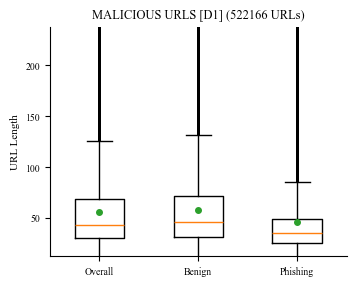

C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3990298510.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(



DATASET: UCI phiusiil-phishing [D2]


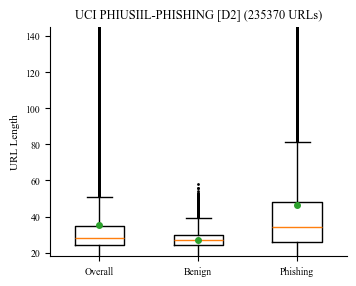


DATASET: kmack Phishing urls [D3]


C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3990298510.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


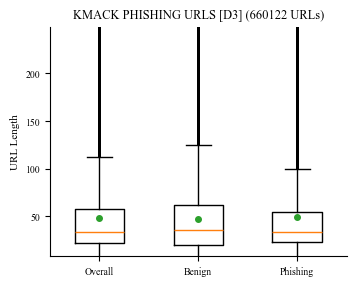


DATASET: kaggels phishing site urls [D4]


C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3990298510.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


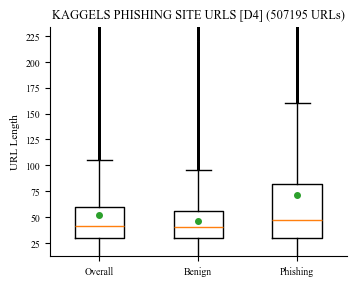

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def draw_boxplots_for_dataset(name, df):
    # URL length
    df["url_len"] = df["url"].astype(str).apply(len)

    # Data groups
    overall = df["url_len"]
    safe = df[df["label"] == 0]["url_len"]
    phishing = df[df["label"] == 1]["url_len"]

    data = [overall, safe, phishing]

    # Robust scaling using percentiles (IEEE-friendly)
    all_values = np.concatenate(data)
    y_min = np.percentile(all_values, 1)
    y_max = np.percentile(all_values, 99)

    # Plot
    plt.figure(figsize=(3.5, 2.8))  # IEEE single-column size

    plt.boxplot(
        data,
        labels=["Overall", "Benign", "Phishing"],
        showmeans=True,
        widths=0.5,
        meanprops=dict(marker='o', markersize=4),
        flierprops=dict(marker='.', markersize=2),
    )

    plt.title(f"{name.upper()} ({len(df)} URLs)", fontsize=9)
    plt.ylabel("URL Length", fontsize=8)

    # Proper scaling
    plt.ylim(y_min, y_max)

    # Remove grid & extra spines (IEEE clean look)
    plt.grid(False)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)

    plt.tight_layout(pad=0.6)
    plt.show()

gen = all_dataset()
for name, splits in gen:
    print(f"\n==============================")
    print(f"DATASET: {name}")
    print("==============================")

    # Print info + ratios
    main = pd.concat(splits)
    # Draw 3-subplot figure
    draw_boxplots_for_dataset(name, main)

C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3425775091.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3425775091.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3425775091.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
C:\Users\rrpra\AppData\Local\Temp\ipykernel_11404\3425775091.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxpl

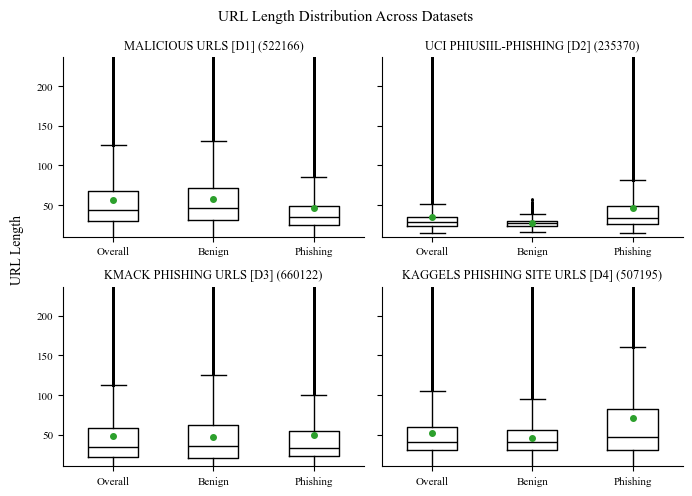

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------- Load datasets ----------
gen = list(all_dataset())[:4]   # Use first 4 datasets


# ---------- Step 1: Compute GLOBAL y-axis limits ----------
all_vals = []

for name, splits in gen:
    df = pd.concat(splits)
    df["url_len"] = df["url"].astype(str).apply(len)
    all_vals.extend(df["url_len"].values)

# Robust percentile scaling (paper-friendly)
y_min = np.percentile(all_vals, 1)
y_max = np.percentile(all_vals, 99)


# ---------- Step 2: Create 2x2 grid with shared Y ----------
fig, axes = plt.subplots(
    2, 2,
    figsize=(7, 5),     # Double-column IEEE size
    sharey=True
)

axes = axes.flatten()


# ---------- Step 3: Plot each dataset ----------
for i, (name, splits) in enumerate(gen):

    df = pd.concat(splits)
    df["url_len"] = df["url"].astype(str).apply(len)

    # Data groups
    overall  = df["url_len"]
    benign   = df[df["label"] == 0]["url_len"]
    phishing = df[df["label"] == 1]["url_len"]

    data = [overall, benign, phishing]

    ax = axes[i]

    ax.boxplot(
        data,
        labels=["Overall", "Benign", "Phishing"],
        showmeans=True,
        widths=0.5,
        medianprops=dict(color="black"),
        meanprops=dict(marker='o', markersize=4),
        flierprops=dict(marker='.', markersize=2),
    )

    ax.set_title(f"{name.upper()} ({len(df)})", fontsize=9)
    ax.set_ylim(y_min, y_max)

    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    # Clean IEEE look
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ---------- Step 4: Global labels ----------
fig.supylabel("URL Length", fontsize=10)
fig.suptitle("URL Length Distribution Across Datasets", fontsize=11)

fig.tight_layout(pad=1.2)
plt.show()


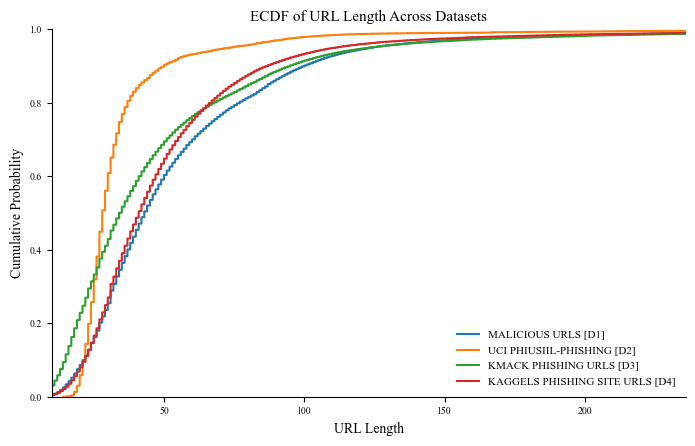

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------- Load datasets ----------
gen = list(all_dataset())[:4]   # First 4 datasets


# ---------- Helper: Compute ECDF ----------
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


# ---------- Collect URL lengths ----------
dataset_lengths = {}
all_vals = []

for name, splits in gen:

    df = pd.concat(splits)
    df["url_len"] = df["url"].astype(str).apply(len)

    vals = df["url_len"].values

    dataset_lengths[name] = vals
    all_vals.extend(vals)


# ---------- Global X limits (robust) ----------
x_min = np.percentile(all_vals, 1)
x_max = np.percentile(all_vals, 99)


# ---------- Plot ECDF ----------
plt.figure(figsize=(7, 4.5))   # IEEE double-column

for name, vals in dataset_lengths.items():

    x, y = ecdf(vals)

    plt.plot(
        x, y,
        linewidth=1.5,
        label=name.upper()
    )


# ---------- Formatting ----------
plt.xlim(x_min, x_max)
plt.ylim(0, 1)

plt.xlabel("URL Length", fontsize=10)
plt.ylabel("Cumulative Probability", fontsize=10)

plt.title("ECDF of URL Length Across Datasets", fontsize=11)

plt.legend(fontsize=8, frameon=False)

plt.grid(False)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [6]:
# get url maxlen
lens = []

for name, splits in all_dataset():
    print(name)
    for df in splits[0:2]:
        lens.extend(df["url"].astype(str).apply(len).tolist())

import numpy as np
lens = np.array(lens)

print("90th percentile:", np.percentile(lens, 90))
print("95th percentile:", np.percentile(lens, 95))
print("99th percentile:", np.percentile(lens, 99))
print("Max:", lens.max())


Malicious URLs [D1]
UCI phiusiil-phishing [D2]
kmack Phishing urls [D3]
kaggels phishing site urls [D4]
90th percentile: 91.0
95th percentile: 116.0
99th percentile: 236.0
Max: 6097
